# Example: Computing Stylized Facts for Daily Equity Growth Rates
A __stylized fact__ is an empirical pattern that appears repeatedly across assets and time periods, although it need not hold exactly for every asset or every sample. Daily equity growth rates commonly exhibit three such patterns: their distributions place more probability in the tails than a Normal model, their signed values have little linear dependence beyond short lags, and the sizes of their movements cluster through time.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Growth rates and volatility scales:__ Construct a continuously compounded growth-rate series from a price history and plot its path over time. Distinguish the volatility of the growth rate from the volatility of the log return over one interval and from the annualized reporting convention.
> * __Distributional shape and tails:__ Compare an empirical growth-rate distribution against candidate parametric models to judge peakedness and tail weight. Estimate a tail index and check how far that estimate moves as the cutoff defining the tail changes.
> * __Autocorrelation and volatility clustering:__ Compute and compare the autocorrelation of growth rates and their magnitudes. Explain how weak growth-rate autocorrelation can coexist with persistent movement sizes.

In this example, we construct a daily growth-rate series from closing prices and then examine each pattern for one equity. All notation and diagnostics are introduced as they are needed, so the notebook does not require the accompanying lecture notes. Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
# Load the shared L3a paths, course environment, and package imports.
include(joinpath(@__DIR__, "Include.jl"));

For package-specific details, see the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/). The shared setup also loads the tabular-data, probability, hypothesis-testing, and plotting tools used below.


### Data

The frozen course dataset contains one table for each security. A security is identified by its __ticker symbol__, such as `AMD`. Each table contains a chronologically ordered sequence of daily open, high, low, and closing prices. The analysis below uses the closing price from each trading day.

The complete collection is stored as a Julia dictionary: each key is a ticker symbol, and the corresponding value is a `DataFrame` containing that security's price history.


In [2]:
# Load the frozen daily equity dataset supplied by the course package.
original_dataset = MyTrainingMarketDataSet() |> data -> data["dataset"];

Not every ticker has the same number of records. Listings, acquisitions, delistings, and missing observations can shorten a price history. Because [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) constructs a rectangular matrix, we retain the tickers with the maximum available history. This produces a balanced sample in which every retained security contributes the same number of observations. It also excludes shorter histories, so conclusions from this notebook apply to the retained sample rather than automatically to every security in the original dataset.

First, compute that maximum history length.


In [3]:
# Find the longest price history in the original ticker universe.
maximum_number_trading_days = maximum(nrow(frame) for frame in values(original_dataset))

2767

Now collect the ticker histories having exactly `maximum_number_trading_days` observations. We store the result in `dataset::Dict{String,DataFrame}`.


In [4]:
# Retain ticker histories with the maximum number of trading-day records.
dataset = let
    cleaned = Dict{String,DataFrame}(); # ticker-to-DataFrame mapping for complete histories
    for (ticker, frame) in original_dataset # unpack one ticker-history pair
        if nrow(frame) == maximum_number_trading_days # exclude shorter listing or delisting histories
            cleaned[ticker] = frame; # retain the full DataFrame under its ticker symbol
        end
    end
    cleaned
end;

How much of the original universe remains after the complete-history filter?


In [5]:
# Summarize the effect of the complete-history filter.
data_summary = DataFrame( # one-row audit table for the history-length filter
    available_tickers=length(original_dataset),
    complete_history_tickers=length(dataset),
    trading_days=maximum_number_trading_days,
);
pretty_table(data_summary; table_format=TextTableFormat(borders=text_table_borders__simple))

==================== ========================== ===============
  available_tickers   complete_history_tickers   trading_days 
              Int64                      Int64          Int64 
==================== ========================== ===============
                515                        424           2767
==================== ========================== ===============


Finally, collect and alphabetize the retained ticker symbols. The position of a ticker in `list_of_tickers` will identify its column in the growth-rate matrix.


In [6]:
# Fix a reproducible alphabetical column order for the growth-rate matrix.
list_of_tickers = keys(dataset) |> collect |> sort;

___


## Task 1: Compute the Growth-Rate Matrix

In this task, we'll turn the daily closing prices into a matrix of continuously compounded growth rates $\mathbf{G}\in\mathbb{R}^{(T-1)\times{N}}$, with one row per trading day and one column per security. Every diagnostic later in this notebook reads from this matrix, so we build it first.

Suppose the cleaned dataset contains $N$ securities observed on $T$ consecutive trading days. We use the following notation:

* $i\in\{1,\ldots,N\}$ identifies a security.
* $j\in\{1,\ldots,T\}$ identifies a trading day.
* $S_j^{(i)}>0$ is the closing share price of security $i$ on trading day $j$, measured in USD/share.
* $t_j$ is the time of observation $j$, measured in years.
* $\Delta t_j=t_j-t_{j-1}$ is the elapsed time between observations $j-1$ and $j$. For equally spaced daily data, we use $\Delta t_j=1/252$ year because a trading year contains approximately 252 trading days.
* $g_{j,j-1}^{(i)}$ is the continuously compounded growth rate of security $i$ over the interval from $t_{j-1}$ to $t_j$, measured in inverse years.

The continuously compounded growth rate is defined by the price-evolution equation:

$$
S_j^{(i)}=S_{j-1}^{(i)}\exp\!\left(g_{j,j-1}^{(i)}\Delta t_j\right).
$$

Dividing by $S_{j-1}^{(i)}$, taking the natural logarithm, and solving for $g_{j,j-1}^{(i)}$ gives:

$$
g_{j,j-1}^{(i)}=\frac{1}{\Delta t_j}\log\!\left(\frac{S_j^{(i)}}{S_{j-1}^{(i)}}\right).
$$

A positive value of $g_{j,j-1}^{(i)}$ means the closing price increased over the interval, and a negative value means it decreased. The associated __log return__ is:

$$
r_{j,j-1}^{(i)}=\log\!\left(\frac{S_j^{(i)}}{S_{j-1}^{(i)}}\right)=(\Delta t_j)g_{j,j-1}^{(i)}.
$$

The log return $r_{j,j-1}^{(i)}$ is dimensionless, whereas the growth rate $g_{j,j-1}^{(i)}$ has units of inverse years. From $T$ prices we obtain $T-1$ growth rates. The function `log_growth_matrix(...)` collects them in a matrix $G\in\mathbb{R}^{(T-1)\times N}$: row $j-1$ corresponds to the interval from day $j-1$ to day $j$, and column $i$ corresponds to security $i$. The optional `risk_free_rate` argument can subtract the annualized growth rate of a reference investment treated as risk-free. 

We set `risk_free_rate=0.0`, so $G$ contains the securities' ordinary growth rates rather than excess growth rates relative to that benchmark.


In [7]:
# Compute annualized daily growth rates from closing-price observations.
Δt = 1 / 252;  # one trading-day step in units of trading years
growth_rate_array = log_growth_matrix(
    dataset, # compute the growth-rate matrix from the dataset
    list_of_tickers; # which tickers to include in the growth-rate matrix
    Δt=Δt, # time step in years
    risk_free_rate=0.0, # ordinary growth rates, not excess growth rates
    keycol=:close,  # use daily closing prices
);

### Select a Ticker and Visualize Its Growth-Rate Series

The array `list_of_tickers` determines the column order of $G$. We select the column associated with the ticker stored in `ticker_to_visualize` and call the resulting $(T-1)$-element vector `growth_rate`. Every subsequent diagnostic uses this same growth-rate series. The default choice below is `AMD`. To rerun the analysis for a different security, set `ticker_to_visualize` to any symbol in `list_of_tickers` and re-execute the notebook from this cell.

In [8]:
# Select one ticker and extract its growth-rate series from G.
ticker_to_visualize = "AMD";
ticker_index = only(findall(==(ticker_to_visualize), list_of_tickers)); # require exactly one matching matrix column
growth_rate = growth_rate_array[:, ticker_index]; # annualized daily growth-rate series for the selected firm

Let's plot the growth-rate series over time for the ticker that you selected. The horizontal axis is the trading day index, and the vertical axis is the growth rate in inverse years. 

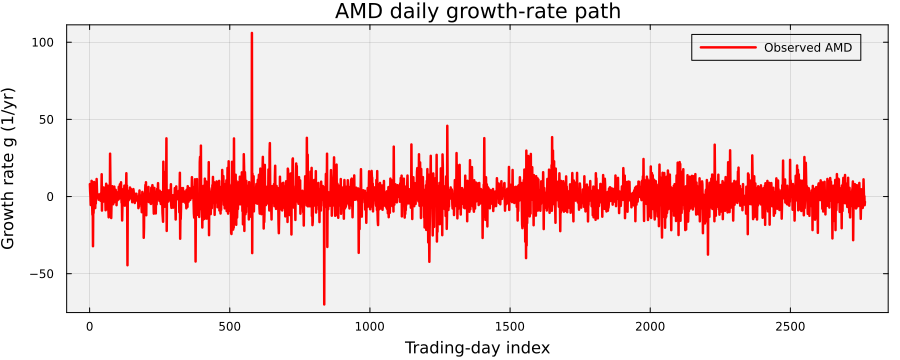

In [9]:
# Plot the ordered series to reveal extremes and volatility clusters.
plot(
    growth_rate;
    label="Observed $(ticker_to_visualize)",
    color=:red,
    linewidth=2.5,
    xlabel="Trading-day index",
    ylabel="Growth rate g (1/yr)",
    title="$(ticker_to_visualize) daily growth-rate path",
    background_color=:gray95,
    background_color_outside=:white,
    framestyle=:box,
    legend_background_color=nothing,
    left_margin=3Plots.mm,
    bottom_margin=4Plots.mm,
    size=(900, 360),
)

The series fluctuates around a value close to zero, but its variation is not uniform through time. Quiet intervals are interrupted by isolated extremes and by episodes containing many large movements. The path therefore raises two different questions:

1. Does one fixed probability distribution describe the size of the daily movements?
2. Are the movements independent through time?

We address the distributional question first. To simplify notation for the selected security, write $g_t$ for its growth rate during interval $t$. The corresponding log return is $r_t=(\Delta t)g_t$. Because $\Delta t$ is the same positive constant for every observation, $g_t$ and $r_t$ have the same distributional shape, autocorrelation, and tail index. Only their numerical scales and units differ. To keep the notebook internally consistent, every diagnostic below is computed from the annualized growth-rate series $\{g_t\}_{t=1}^{T-1}$.

For this fixed interval, define the __growth-rate volatility__ $\sigma_g=\operatorname{std}(g_t)$ and the __interval log-return volatility__ $\sigma_r(\Delta t)=\operatorname{std}(r_t)$. They describe the same sample dispersion in different units and satisfy the exact identity $\sigma_r(\Delta t)=(\Delta t)\sigma_g$. The __annualized log-return volatility__ convention is $\sigma_{\mathrm{ann}}=\sigma_r(\Delta t)/\sqrt{\Delta t}=\sqrt{\Delta t}\,\sigma_g$. Unlike the fixed-interval identity, interpreting this annualized value across horizons assumes uncorrelated increments with stable variance.


In [10]:
# Compute equivalent fixed-interval dispersions and conventional annualized volatility.
log_return = Δt .* growth_rate;  # dimensionless one-day log returns
growth_rate_volatility = std(growth_rate);  # σ_g, units 1/year
interval_log_return_volatility = std(log_return);  # σ_r(Δt), dimensionless
annualized_log_return_volatility = interval_log_return_volatility / sqrt(Δt);  # units 1/√year

# Check the exact change-of-units identity and its annualized conversion.
@assert interval_log_return_volatility ≈ Δt * growth_rate_volatility
@assert annualized_log_return_volatility ≈ sqrt(Δt) * growth_rate_volatility

# Display each measure with its statistical name and units.
series_summary = DataFrame(
    statistic=[
        "Mean growth rate",
        "Growth-rate volatility",
        "Interval log-return volatility",
        "Annualized log-return volatility",
    ],
    value=[
        mean(growth_rate),
        growth_rate_volatility,
        interval_log_return_volatility,
        annualized_log_return_volatility,
    ],
    units=["1/year", "1/year", "dimensionless over Δt", "1/√year"],
);
println("Ticker: $(ticker_to_visualize) | Observations: $(length(growth_rate))")
pretty_table(series_summary; table_format=TextTableFormat(borders=text_table_borders__simple))

Ticker: AMD | Observations: 2766
=================================== =========== ========================
                         statistic       value                   units 
                            String     Float64                  String 
=================================== =========== ========================
                  Mean growth rate    0.310468                  1/year
            Growth-rate volatility     8.96318                  1/year
    Interval log-return volatility   0.0355682   dimensionless over Δt
  Annualized log-return volatility    0.564627                 1/√year
=================================== =========== ========================


___


## Task 2: Are Daily Growth Rates Normally Distributed?

In this task, we'll fit three candidate distributions to one security's daily growth rates and see which one matches the data. We then estimate the tail index, which measures how fast the chance of an extreme day falls off.

Let $g_1,\ldots,g_n$ denote the $n=T-1$ observed annualized growth rates in `growth_rate`. A common benchmark treats these observations as __independent and identically distributed__ (i.i.d.) draws from a Normal distribution. “Identically distributed” means that one fixed distribution describes every trading-day interval. “Independent” means that knowing past growth rates provides no information about a future growth rate. This task examines the distributional assumption. Task 3 examines temporal dependence.

The empirical growth-rate density is typically more sharply concentrated near zero and places more probability far from zero than a fitted Normal density. This excess tail probability is commonly called a __fat-tail__ or __heavy-tail relative to the Normal__ effect.

We compare three symmetric models:

| Model | Parameters and shape |
|:--|:--|
| Normal | Location $\mu$ and scale $\sigma>0$, with a smooth center and tails proportional to $\exp(-x^2)$ |
| Laplace | Location $m$ and scale $b>0$, with a sharper center and tails proportional to $\exp(-\lvert x\rvert)$ |
| Student-t | Location, scale, and degrees of freedom $\nu$, where smaller $\nu$ produces slower, power-law tail decay |

__Maximum-likelihood estimation__ chooses model parameters that maximize the probability density assigned to the observed sample. We fit the Normal and Laplace parameters by maximum likelihood. For the Student-t model, we compare a small grid of $\nu$ values. At each candidate $\nu$, the location equals the sample mean and the scale is chosen to match the sample variance. The candidate with the largest sample log likelihood is retained.


In [11]:
# Fit the two-parameter models by maximum likelihood.
normal_fit = fit_mle(Normal, growth_rate); # estimate Normal location and scale
laplace_fit = fit_mle(Laplace, growth_rate); # estimate Laplace location and scale

# Compare variance-matched Student-t candidates across a degrees-of-freedom grid.
ν_grid = [2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 30.0]; # finite-variance candidates require ν > 2
student_candidates = [
    LocationScale(
        mean(growth_rate),
        std(growth_rate) * sqrt((ν_candidate - 2) / ν_candidate), # scale chosen to match sample variance
        TDist(ν_candidate),
    ) for ν_candidate in ν_grid
];
student_log_likelihoods = [
    sum(logpdf.(distribution, growth_rate)) for distribution in student_candidates
];
best_student_index = argmax(student_log_likelihoods); # maximum-likelihood grid position
student_dof = ν_grid[best_student_index]; # selected degrees of freedom
student_fit = student_candidates[best_student_index]; # variance-matched fitted distribution

### Compare the Empirical and Fitted Densities

A probability density describes how probability is distributed across possible growth-rate values. The red “Observed” curve is a kernel-density estimate: a smooth, nonparametric estimate constructed directly from $g_1,\ldots,g_n$. The other curves are the fitted parametric densities.

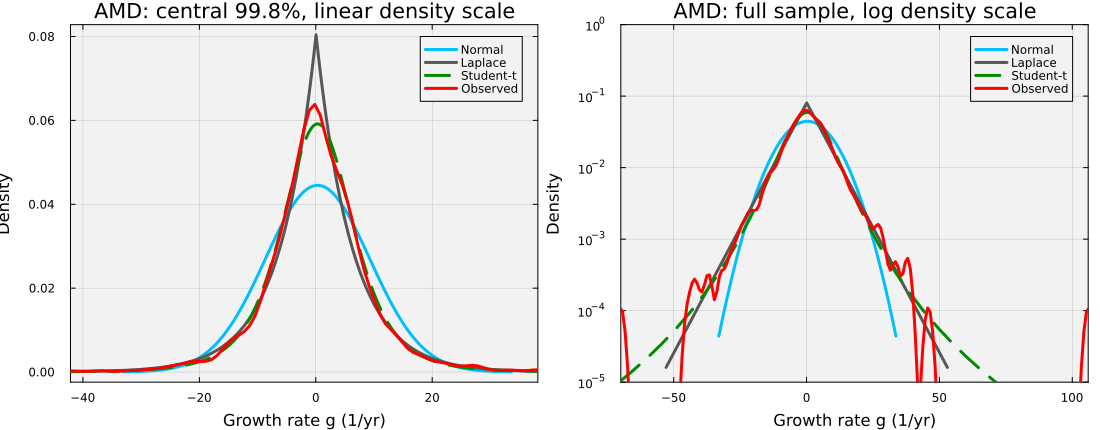

In [12]:
# Use a central-range linear panel and a full-range logarithmic tail panel.
growth_rate_central_limits = quantile(growth_rate, [0.001, 0.999]); # suppress the outer 0.2% in the central panel
growth_rate_full_limits = extrema(growth_rate); # retain every observation in the tail panel

p_linear = plot(
    normal_fit;
    label="Normal", color=:deepskyblue1, linewidth=3,
    xlims=(growth_rate_central_limits[1], growth_rate_central_limits[2]),
    xlabel="Growth rate g (1/yr)", ylabel="Density",
    title="$(ticker_to_visualize): central 99.8%, linear density scale", framestyle=:box,
    background_color=:gray95, background_color_outside=:white,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
);
plot!(p_linear, laplace_fit; label="Laplace", color=:grey34, linewidth=3);
plot!(p_linear, student_fit; label="Student-t", color=:green4, linewidth=3, linestyle=:dash);
density!(p_linear, growth_rate; label="Observed", color=:red, linewidth=3);

p_log = plot(
    normal_fit;
    label="Normal", color=:deepskyblue1, linewidth=3,
    xlims=(growth_rate_full_limits[1], growth_rate_full_limits[2]),
    ylims=(1e-5, 1e0), yscale=:log10,
    xlabel="Growth rate g (1/yr)", ylabel="Density",
    title="$(ticker_to_visualize): full sample, log density scale", framestyle=:box,
    background_color=:gray95, background_color_outside=:white,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
);
plot!(p_log, laplace_fit; label="Laplace", color=:grey34, linewidth=3);
plot!(p_log, student_fit; label="Student-t", color=:green4, linewidth=3, linestyle=:dash);
density!(p_log, growth_rate; label="Observed", color=:red, linewidth=3);

plot(p_linear, p_log; layout=(1, 2), size=(1100, 430))

__What do we observe?__ The fitted Normal density is too broad near the center and decays too quickly in the tails. The left panel shows the center problem. It uses a linear density axis over the central 99.8% of the data, so the peak stays readable. The right panel shows the tail problem. It uses a base-10 log density axis over the full growth-rate range, which pulls the curves apart where the densities get tiny. A model can fit the center well and still get the tails badly wrong.

The Laplace and Student-t models capture different parts of the empirical shape more successfully. Visual agreement is useful, but we should also compare the fitted models numerically.

* __For a numerical comparison, we report two diagnostics.__ The Anderson–Darling statistic compares the empirical CDF $F_n(x)$ with the fitted CDF $F(x)$ while emphasizing tail discrepancies (smaller is better). The log likelihood, $\ell=\sum_{t=1}^{n}\log f(g_t)$, sums the fitted log density across observations. It is not a probability and can be negative. For models evaluated on the same data and units, larger (less negative) is better.

Because each model is estimated from the same observations used for comparison, we treat both quantities as relative fit diagnostics rather than using an unadjusted Anderson–Darling p-value as a definitive accept-or-reject decision.


In [13]:
# Compare tail-weighted CDF error and sample log likelihood across fitted models.
fitted_models = [
    ("Normal", normal_fit),
    ("Laplace", laplace_fit),
    ("Student-t (ν=$(student_dof))", student_fit),
];

fit_comparison = DataFrame( # one row per fitted parametric family
    distribution=first.(fitted_models),
    AD_statistic=[
        OneSampleADTest(growth_rate, distribution).A²
        for (_, distribution) in fitted_models
    ],
    log_likelihood=[
        sum(logpdf.(distribution, growth_rate))
        for (_, distribution) in fitted_models
    ],
);
sort!(fit_comparison, :AD_statistic); # place the best tail-sensitive CDF fit first

# Label the preferred direction for each diagnostic in the displayed table.
rename!(
    fit_comparison,
    :AD_statistic => Symbol("AD (smaller is better)"),
    :log_likelihood => Symbol("log L (larger is better)"),
);
pretty_table(fit_comparison; table_format=TextTableFormat(borders=text_table_borders__simple))

==================== ======================== ===========================
       distribution   AD (smaller is better)   log L (larger is better) 
             String                  Float64                    Float64 
==================== ======================== ===========================
  Student-t (ν=4.0)                  1.23176                   -9727.11
            Laplace                  2.29591                   -9736.87
             Normal                  31.1763                   -9990.47
==================== ======================== ===========================


### A Test With a Yes-or-No Answer

The table ranks the three models, but it does not tell us whether to reject any of them. We fit each model on the same data we then test it against, which leaves the usual Anderson-Darling p-value too generous to trust.

The __Jarque-Bera test__ is built for that situation, because it expects the mean and the variance to be estimated from the sample. It checks two shape numbers against what a Normal distribution requires:

* __Skewness__ measures how lopsided the distribution is. A Normal distribution is symmetric, so its skewness is 0, and a nonzero sample value means one tail runs longer than the other.
* __Kurtosis__ measures how much probability sits far from the center. A Normal distribution has kurtosis 3, and a larger value means extreme days happen more often than the Normal allows.

The null hypothesis is that the growth rates are Normal. A large statistic and a small p-value tell us to reject it. The p-value also assumes the observations are independent, so read it as strong evidence about shape rather than an exact probability.

In [14]:
# Test Normality from sample skewness and kurtosis, which tolerates estimated parameters.
jarque_bera = JarqueBeraTest(growth_rate);

println("Jarque-Bera test for $(ticker_to_visualize)")
println("  skewness     = $(round(jarque_bera.skew, digits=3))\t(Normal: 0)")
println("  kurtosis     = $(round(jarque_bera.kurt, digits=3))\t(Normal: 3)")
println("  JB statistic = $(round(jarque_bera.JB, digits=1))")
println("  p-value      = $(pvalue(jarque_bera))")

Jarque-Bera test for AMD
  skewness     = 0.436	(Normal: 0)
  kurtosis     = 13.595	(Normal: 3)
  JB statistic = 13024.5
  p-value      = 0.0


The kurtosis is 13.6, more than four times the Normal value of 3. The p-value is zero to machine precision, so we reject Normality at every usual level. The density plot showed this by eye, and the test now puts a number on it. This is the accept-or-reject answer the Anderson-Darling table could not give us.

The skewness of 0.44 is small next to the kurtosis, so the heavy tails, not lopsidedness, drive the rejection. The tails are heavy. How heavy is the next question.

### Estimate the Tail Index

The density comparison shows that the Normal model misses the tails, but it does not summarize how quickly the probability of an extreme observation decreases. Define the nonnegative magnitude series $X_t=|g_t|$. A power-law tail has the approximate form:

$$
\mathbb{P}(X>x)\approx Cx^{-\alpha}\qquad\text{for large }x,
$$

where $C>0$ is a constant and $\alpha>0$ is the __tail index__. Smaller $\alpha$ means slower tail decay and therefore a greater relative frequency of extreme observations.

Let $n$ be the number of positive magnitudes and sort them from largest to smallest: $X_{(1)}\geq X_{(2)}\geq\cdots\geq X_{(n)}$. Hill's estimator uses the $k$ largest magnitudes and the next observation, $X_{(k+1)}$, as a threshold:

$$
\widehat{\alpha}_k=\left[\frac{1}{k}\sum_{m=1}^{k}\log\!\left(\frac{X_{(m)}}{X_{(k+1)}}\right)\right]^{-1}.
$$

The integer $k$ is not a model parameter but the analyst's choice of how many extreme observations count as the tail. A very small $k$ produces a noisy estimate, while a large $k$ mixes ordinary observations from the body of the distribution into the tail calculation. We therefore examine $\widehat{\alpha}_k$ across a range of $k$ values rather than reporting one arbitrary result.


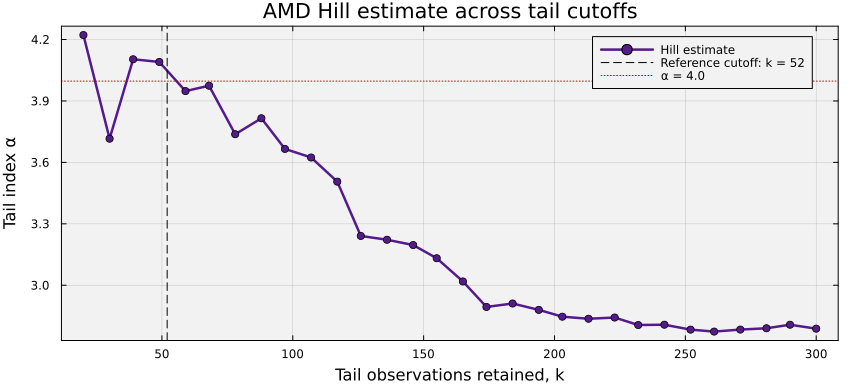

In [15]:
# Evaluate Hill estimates across cutoffs and mark the √n reference choice.
number_of_tail_observations = count(>(0), abs.(growth_rate)); # zero magnitudes cannot enter log tail ratios
maximum_k = min(300, number_of_tail_observations - 1); # keep at least one observation outside the fitted tail
hill_k = unique(round.(Int, range(20, maximum_k; length=30))); # candidate upper-tail sample sizes
hill_alpha = [
    hill_tail_index(growth_rate; k=k, tail=:absolute) for k in hill_k
];
reference_k = floor(Int, sqrt(number_of_tail_observations)); # conventional exploratory cutoff
reference_alpha = hill_tail_index(
    growth_rate; k=reference_k, tail=:absolute
);

plot(
    hill_k, hill_alpha;
    marker=:circle, markersize=4, color=:purple4, linewidth=2.5,
    label="Hill estimate", xlabel="Tail observations retained, k",
    ylabel="Tail index α", title="$(ticker_to_visualize) Hill estimate across tail cutoffs",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
vline!([reference_k]; color=:black, linestyle=:dash,
    label="Reference cutoff: k = $(reference_k)");
hline!([reference_alpha]; color=:red3, linestyle=:dot,
    label="α = $(round(reference_alpha, digits=2))")

A plateau over a meaningful range of $k$ would support a stable tail-index estimate. Drift across the plot indicates cutoff sensitivity. The vertical line at $k=\lfloor\sqrt{n}\rfloor$ is a reproducible reference, not a uniquely correct cutoff.


___


## Task 3: Autocorrelation and Volatility Clustering

Task 2 examined the distribution of daily growth rates without using their order in time. We now ask whether growth rates on different days are related:

1. Is a growth rate $g_t$ linearly related to a later growth rate $g_{t+k}$?
2. Do large growth-rate magnitudes $|g_t|$ tend to occur together?

We answer both questions with the __autocorrelation function (ACF)__. The lag $k$ tells us how far apart the observations are: $k=1$ compares consecutive trading days, and $k=5$ compares days about one trading week apart.

### Growth-Rate Autocorrelation

We use the lecture's notation for the selected security: $g_2,\ldots,g_T$ are the $T-1$ growth rates obtained from $T$ prices, and $g^{\prime}$ is their sample mean. This is the same series called $g_1,\ldots,g_n$ in Task 2, with $n=T-1$; only the indices change. In the code, `growth_rate[t-1]` corresponds to $g_t$.

First, measure how growth rates at lag $k$ vary together around their mean:

$$
\hat{R}(k)=\frac{1}{T-1}\sum_{t=2}^{T-k}(g_t-g^{\prime})(g_{t+k}-g^{\prime}).
$$

Then divide by the value at lag zero to obtain the ACF:

$$
\boxed{\rho(k)=\frac{\hat{R}(k)}{\hat{R}(0)}}, \qquad k=0,1,\ldots,T-2.
$$

The ACF lies between $-1$ and $1$, with $\rho(0)=1$. Positive values indicate that deviations from the mean tend to have the same sign at that lag; negative values indicate opposite signs. Values near zero indicate little linear relationship.

The lecture's random-walk benchmark suggests an ACF near zero for $k>0$. We plot lags 1 through 252, or about one trading year. The dashed lines at $\pm 1.96/\sqrt{T-1}$ give an approximate 95% reference band for each lag under an i.i.d. benchmark. A few bars can fall outside this band by chance; the band does not test all 252 lags together.

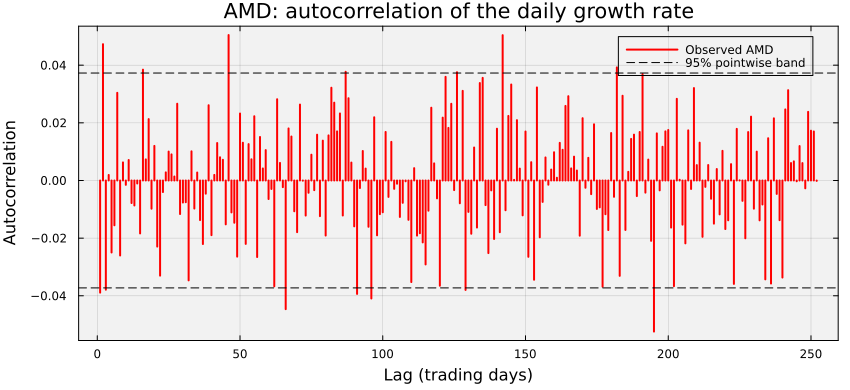

In [16]:
# Compute the growth-rate ACF -
growth_lags = collect(1:252);  # lags out to one trading year
growth_acf = sample_autocorrelation(growth_rate, growth_lags); # ρ(k) = R̂(k)/R̂(0)
pointwise_band = 1.96 / sqrt(length(growth_rate)); # approximate 95% null band at each lag

plot(
    growth_lags, growth_acf;
    seriestype=:sticks, color=:red, linewidth=2,
    label="Observed $(ticker_to_visualize)",
    xlabel="Lag (trading days)", ylabel="Autocorrelation",
    title="$(ticker_to_visualize): autocorrelation of the daily growth rate",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, legend_background_color=nothing,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
hline!([pointwise_band, -pointwise_band];
    color=:black, linestyle=:dash, label="95% pointwise band")

For AMD, the growth-rate autocorrelations are small and mostly close to zero over the lags shown. Some bars cross the reference band, but there is no broad pattern of large autocorrelations.

Weak autocorrelation does not establish independence. Large positive and negative growth rates may still occur in the same periods. To examine that pattern, we next compute the ACF of their magnitudes.

### Volatility Clustering

__Volatility clustering__ means that large movements tend to occur together, as do small movements, regardless of whether prices rise or fall. Taking the absolute value $|g_t|$ keeps the size of each growth rate and removes its sign. A single magnitude is not a standard deviation, but a sequence of magnitudes helps us identify periods of larger or smaller variation.

We repeat the lecture's ACF calculation using $|g_t|$ in place of $g_t$ and the mean magnitude in place of $g^{\prime}$:

$$
\overline{|g|}=\frac{1}{T-1}\sum_{t=2}^{T}|g_t|.
$$

Positive magnitude autocorrelations over many lags are evidence of volatility clustering. We use the same lag range so that we can compare the two plots directly.

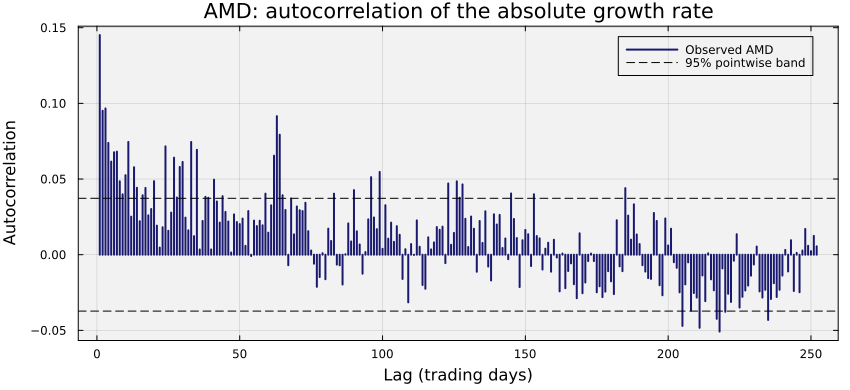

In [17]:
# Compute the growth-rate-magnitude ACF -
volatility_lags = collect(1:252);
absolute_growth_acf = sample_autocorrelation(abs.(growth_rate), volatility_lags);

plot(
    volatility_lags, absolute_growth_acf;
    seriestype=:sticks, color=:midnightblue, linewidth=2,
    label="Observed $(ticker_to_visualize)",
    xlabel="Lag (trading days)", ylabel="Autocorrelation",
    title="$(ticker_to_visualize): autocorrelation of the absolute growth rate",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, legend_background_color=nothing,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
hline!([pointwise_band, -pointwise_band];
    color=:black, linestyle=:dash, label="95% pointwise band")

For AMD, the magnitude ACF starts near $0.15$ and remains positive at nearly every lag through the first three months. The positive autocorrelations extend across many lags, indicating that movement sizes are related over time.

The two plots show the main result: growth-rate autocorrelations are mostly close to zero, while magnitude autocorrelations remain positive over many lags. Large movements tend to occur together, even when the growth rates themselves have little linear relationship across days. This is the volatility-clustering pattern described in the lecture.

___

## Optional Extension: The Ljung–Box Test

The ACF plots provide the main comparison for Task 3. The optional __Ljung–Box test__ adds a numerical check by testing several lags together.

The null hypothesis is that the autocorrelations at lags 1 through $L$ are all zero. The statistic $Q$ combines their squared values; a small p-value is evidence against that hypothesis under the test's assumptions.

We apply the test to $g_t$ and $|g_t|$ using $L=10$, 21, and 63 trading days: about two weeks, one month, and one quarter. These tests overlap because each larger lag range includes the smaller ones. Treat the table as an exploratory comparison. Volatility clustering can affect the usual p-value calibration, so the growth-rate test needs particular care.

In [18]:
# Test the first L autocorrelations for growth rates and their magnitudes -
ljung_box_lags = [10, 21, 63]; # roughly two weeks, one month, and one quarter

ljung_box_results = DataFrame(
    lags=ljung_box_lags,
    Q_signed=[LjungBoxTest(growth_rate, lag).Q for lag in ljung_box_lags],
    p_signed=[pvalue(LjungBoxTest(growth_rate, lag)) for lag in ljung_box_lags],
    Q_absolute=[LjungBoxTest(abs.(growth_rate), lag).Q for lag in ljung_box_lags],
    p_absolute=[pvalue(LjungBoxTest(abs.(growth_rate), lag)) for lag in ljung_box_lags],
);
# Display the joint statistic and p-value for each lag range -
pretty_table(ljung_box_results;
    column_labels = ["Lags (trading days)", "Q, signed g", "p, signed g", "Q, |g|", "p, |g|"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.2f", [2, 4]), fmt__printf("%.4f", [3])])

====================== ============= ============= ======== ==============
  Lags (trading days)   Q, signed g   p, signed g   Q, |g|        p, |g| 
====================== ============= ============= ======== ==============
                   10         21.34        0.0189   179.13   3.54883e-33
                   21         30.46        0.0831   234.18   6.04147e-38
                   63         71.71        0.2113   406.20     1.208e-51
====================== ============= ============= ======== ==============


For AMD, the growth-rate p-values are approximately 0.019, 0.083, and 0.211. At the 5% level, only the 10-lag test rejects the hypothesis of zero autocorrelation. The larger tests include those first ten lags but use different rejection thresholds; their results do not establish independence or show that dependence ends after ten days.

For the magnitudes, all three p-values are below $10^{-32}$. This agrees with the persistent positive autocorrelations in the magnitude plot. The table supports the distinction between weak growth-rate autocorrelation and persistent magnitude autocorrelation. Use it alongside the plots and the test assumptions.

___

## Summary

This example constructed an annualized daily growth-rate series from closing prices and used it to examine three stylized facts for AMD.

> __Key Takeaways:__
>
> * __Growth rates and log returns express the same price change in different units:__ The log return over an interval is the growth rate multiplied by the length of that interval, so their volatilities differ by the same factor. The annualized convention divides the interval volatility by the square root of the interval length, which is a reporting choice rather than a property of the data.
> * __The Normal distribution understates extreme growth rates:__ The empirical density is more sharply peaked and carries more probability in its tails than a fitted Normal model. Tail-index estimates quantify that heaviness, but they shift with the cutoff that defines where the tail begins, so a single value means little without its sensitivity.
> * __Weak growth-rate autocorrelation can coexist with volatility clustering:__ Growth-rate autocorrelations are mostly close to zero, while magnitude autocorrelations remain positive over many lags. Large movements tend to occur together, even when the growth rates themselves have little linear relationship across days.

Together, these results show why a useful growth-rate model must be evaluated against distributional shape, extreme-event behavior, and temporal dependence rather than against a single summary statistic.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, and no investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing. Past performance, whether actual or indicated by historical tests, is no guarantee of future performance or success.

__You are fully responsible for any investment or trading decisions you make__. Distributional fits are approximations, Hill estimates are cutoff-sensitive, and the ACF reference bands shown above are pointwise large-sample diagnostics.